### ***Download dataset from kaggle***

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [6]:
!kaggle datasets download -d samuelcortinhas/apples-or-tomatoes-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification
License(s): CC0-1.0
apples-or-tomatoes-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


### ***Unzip Dataset***

In [7]:
!unzip /content/apples-or-tomatoes-image-classification.zip

Archive:  /content/apples-or-tomatoes-image-classification.zip
  inflating: test/apples/img_p1_111.jpeg  
  inflating: test/apples/img_p1_121.jpeg  
  inflating: test/apples/img_p1_127.jpeg  
  inflating: test/apples/img_p1_131.jpeg  
  inflating: test/apples/img_p1_133.jpeg  
  inflating: test/apples/img_p1_139.jpeg  
  inflating: test/apples/img_p1_14.jpeg  
  inflating: test/apples/img_p1_143.jpeg  
  inflating: test/apples/img_p1_15.jpeg  
  inflating: test/apples/img_p1_16.jpeg  
  inflating: test/apples/img_p1_29.jpeg  
  inflating: test/apples/img_p1_30.jpeg  
  inflating: test/apples/img_p1_33.jpeg  
  inflating: test/apples/img_p1_34.jpeg  
  inflating: test/apples/img_p1_36.jpeg  
  inflating: test/apples/img_p1_50.jpeg  
  inflating: test/apples/img_p1_52.jpeg  
  inflating: test/apples/img_p1_55.jpeg  
  inflating: test/apples/img_p1_68.jpeg  
  inflating: test/apples/img_p1_7.jpeg  
  inflating: test/apples/img_p1_70.jpeg  
  inflating: test/apples/img_p1_74.jpeg  
  infla

### ***Import Library***

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.layers import BatchNormalization, Dropout

### ***Loading Data***

In [11]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/train",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/test",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


***`train_ds = keras.utils.image_dataset_from_directory`***  
এখানে আমরা keras.utils module থেকে image_dataset_from_directory() নামের একটা built-in function call করছি, যেটা একটা directory (folder) থেকে সরাসরি images পড়ে একটা tf.data.Dataset object তৈরি করে দেয়। এই function টা internally images read করে, resize করে, batch এ ভাগ করে এবং labels assign করে। এর output টা train_ds variable এ store হচ্ছে, যেটা পরে model.fit() এ ব্যবহার করা হবে training এর জন্য।   
   
***`directory = "/content/train"`***   
এখানে training images-এর folder path দেওয়া হয়েছে। অর্থাৎ, /content/train folder-এর ভিতরে যত subfolder থাকবে, সেখানকার images training dataset হিসেবে load হবে।  
Example:  
/content/train/  
apples/  (Label-1)  
tomatos/ (Label-2)
  
***`labels = "inferred"`***   
labels = "inferred" মানে হলো আমরা Keras কে বলছি labels manually না দিয়ে, subfolder এর নাম দেখে নিজে থেকেই বের করে নিতে (infer করতে)। বিকল্প হিসেবে তুমি labels = None দিতে পারতে (তখন কোনো label থাকবে না, শুধু images), অথবা নিজে একটা list of labels দিতে পারতে। কিন্তু এখানে যেহেতু "inferred" দেওয়া আছে, Keras automatic folder-based labeling করবে।

***`label_mode = "int"`***   
label_mode parameter টা ঠিক করে দেয় labels কোন format এ output হবে। এখানে "int" মানে হলো প্রতিটা class কে একটা integer number দিয়ে represent করা হবে — যেমন যদি দুইটা class থাকে (cat, dog), তাহলে cat = 0, dog = 1 এভাবে number assign হবে (alphabetical order অনুযায়ী)।

***`batch_size = 32`***
Deep learning এ পুরো dataset একসাথে GPU/RAM এ load করে train করা practically সম্ভব হয় না (memory limit থাকে), তাই dataset কে ছোট ছোট ভাগে ভাগ করে train করা হয় — এই ছোট ভাগগুলাকে বলে "batch"। batch_size = 32 মানে প্রতি step এ model কে ৩২টা image + তাদের label একসাথে দেওয়া হবে, model সেই ৩২টার উপর ভিত্তি করে একবার forward pass ও backward pass (gradient update) করবে। batch size বড় হলে training faster হয় কিন্তু বেশি memory লাগে, ছোট হলে memory কম লাগে কিন্তু training slower ও noisy হতে পারে।   
ধরুন মোট 3200টি image আছে।  
3200 ÷ 32 = 100 batches  
অর্থাৎ model এক epoch-এ 100 বার data receive করবে।  

***`image_size = (256, 256)`***  
Real-world dataset এ সাধারণত সব image এর size (height x width) আলাদা আলাদা হয় — কোনোটা 800x600, কোনোটা 1024x768 ইত্যাদি। কিন্তু neural network এর input layer কে একটা fixed shape দিতে হয়, সব image এর size same হতে হবে। তাই image_size = (256, 256) দিয়ে বলা হচ্ছে — প্রতিটা image কে load করার সময় automatically resize করে 256 pixel height ও 256 pixel width এ নিয়ে আসা হবে (aspect ratio বজায় নাও থাকতে পারে, stretch/squeeze হতে পারে)।

### ***Normalization***

In [12]:
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

যদি Normalization না করা হয়, তাহলে pixel values হবে: 0 - 255  
এত বড় range-এর কারণে model-এর training ধীর হতে পারে এবং optimizer-এর জন্য ভালো solution খুঁজে পাওয়া কঠিন হতে পারে।  

Normalization করার পরে: 0.0 - 1.0  
এখন সব input একই scale-এ থাকে।

Neural network এর ভেতরে অনেক ধরনের matrix multiplication ও weight update হয়। যদি input values বড় range এ থাকে (0-255), তাহলে internal computations এ অনেক বড় বড় number তৈরি হতে পারে, যেটা gradient calculation কে unstable করে দিতে পারে। 0-1 range এ আনলে computation stable ও predictable হয়।

***`def process(image, label)`***  
এখানে process() নামে একটি function তৈরি করা হয়েছে।  
এই function প্রতিটি image এবং তার label গ্রহণ করে, image-কে normalize করে এবং পরে image ও label দুটোই return করে।

***`image = tf.cast(image/255. ,tf.float32)`***  
১. image/255. — প্রতিটা pixel value কে 255 দিয়ে ভাগ করা হচ্ছে। কারণ, একটা সাধারণ RGB image এর প্রতিটা pixel এর value থাকে 0 থেকে 255 এর মধ্যে (8-bit integer)। 255 দিয়ে ভাগ করলে সেই value গুলো 0 থেকে 1 এর মধ্যে চলে আসে (যেমন 255 → 1.0, 128 → 0.502, 0 → 0.0)। একেই বলে normalization।

২. tf.cast(..., tf.float32) — ভাগ করার পর value গুলো float হয়ে যায়, কিন্তু TensorFlow এ explicitly data type টাকে float32 তে convert (cast) করে দেওয়া হচ্ছে, যাতে পুরো dataset এ consistent data type থাকে এবং model এর input layer এর সাথে মিলে যায় (deep learning models সাধারণত float32 input আশা করে, কারণ GPU computation float32 তে efficient হয়)।  


### ***Define custom CNN architecture***

In [13]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6293 - loss: 5.8982 - val_accuracy: 0.5567 - val_loss: 2.5957
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7177 - loss: 4.2767 - val_accuracy: 0.5567 - val_loss: 6.5062
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7585 - loss: 2.8435 - val_accuracy: 0.5567 - val_loss: 7.7166
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7755 - loss: 1.8230 - val_accuracy: 0.5567 - val_loss: 16.2222
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7653 - loss: 4.1319 - val_accuracy: 0.5567 - val_loss: 12.3948
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7823 - loss: 3.0292 - val_accuracy: 0.5567 - val_loss: 10.9153
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7993 - loss: 2.1508 - val_accuracy: 0.5670 - val_loss: 10.7232
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8537 - loss: 1.8912 - val_accuracy: 0.5567 

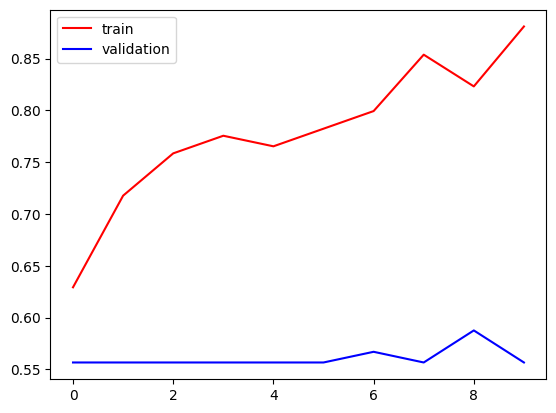

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

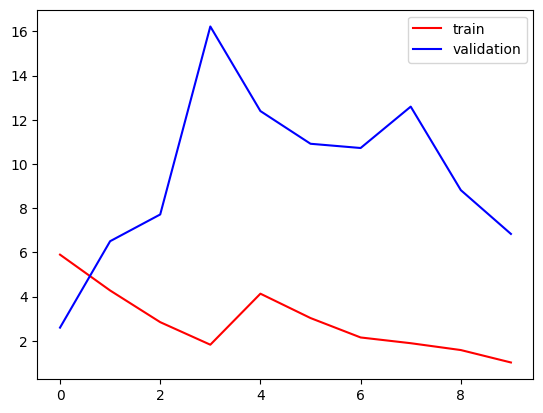

In [18]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

### ***Test a single image***

array([[[  4,  46,  21],
        [ 52,  89,  63],
        [ 53,  84,  55],
        ...,
        [  0,   2,  96],
        [  0,   2,  96],
        [  0,   2,  93]],

       [[ 19,  53,  42],
        [ 34,  65,  50],
        [ 59,  83,  65],
        ...,
        [  0,   0,  94],
        [  0,   1,  92],
        [  1,   2,  93]],

       [[ 49,  72,  74],
        [ 20,  43,  39],
        [ 50,  70,  58],
        ...,
        [  0,   0,  90],
        [  0,   0,  90],
        [  0,   1,  91]],

       ...,

       [[ 51,  72, 193],
        [ 39,  66, 187],
        [ 24,  56, 181],
        ...,
        [  2,   2,   2],
        [  2,   2,   2],
        [  2,   2,   2]],

       [[ 38,  59, 180],
        [ 25,  51, 175],
        [ 11,  44, 171],
        ...,
        [  2,   2,   2],
        [  2,   2,   2],
        [  2,   2,   2]],

       [[ 12,  46, 176],
        [ 12,  45, 178],
        [ 15,  46, 179],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1]]], dtype=uint8)
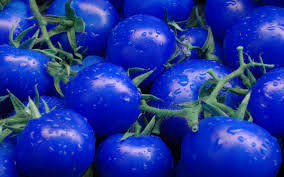

In [42]:
import cv2

test_img = cv2.imread("/content/test/tomatoes/img_p1_88.jpeg")
test_img

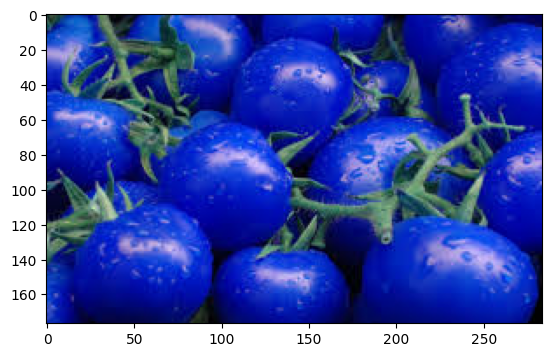

In [43]:
plt.imshow(test_img)

In [44]:
test_img.shape

(177, 284, 3)

In [45]:
test_img = cv2.resize(test_img,(256,256))

In [38]:
test_input = test_img.reshape((1,256,256,3))

In [46]:
result = model.predict(test_input)
if int(result[0][0]) == 0:
  print("Apple")
else:
  print("Tomato")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Tomato
